# Exploratory Chess Analytics

This notebook explores personal chess performance data collected from Chess.com.

Main objectives:
- identify performance patterns
- analyze rating progression
- compare white vs black performance
- evaluate opening effectiveness
- explore behavioral trends

## Imports

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import sys
from pathlib import Path

## Load cleaned dataset

In [124]:
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import USERNAME

DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
    / f"{USERNAME}_games_clean.csv"
)

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,year,month,weekday,hour,side,time_class,time_control,player_rating,opponent_rating,rating_diff,result,player_result,opponent_result,score,opening,opponent,url,opponent_clean,country_code
0,2020-11-10 15:30:24,2020,11,Tuesday,15,white,rapid,600,213,412,-199,loss,resigned,win,0.0,Polish Opening,TheMrNoName,https://www.chess.com/game/live/5719328865,themrnoname,US
1,2020-11-10 15:46:19,2020,11,Tuesday,15,black,rapid,600,345,216,129,win,win,resigned,1.0,Kings Pawn Opening Kings Knight Variation,smackersmashbot,https://www.chess.com/game/live/5719418873,smackersmashbot,PH
2,2020-11-10 16:09:31,2020,11,Tuesday,16,black,rapid,600,256,371,-115,loss,checkmated,win,0.0,Kings Pawn Opening Leonardis Variation,amkh98,https://www.chess.com/game/live/5719482469,amkh98,IR
3,2020-11-10 17:39:54,2020,11,Tuesday,17,white,rapid,600,193,330,-137,loss,checkmated,win,0.0,Vienna Game Max Lange Defense,callumfindlay4,https://www.chess.com/game/live/5720005454,callumfindlay4,GB
4,2020-11-10 17:51:42,2020,11,Tuesday,17,black,rapid,600,277,291,-14,win,win,resigned,1.0,Caro Kann Defense,callumfindlay4,https://www.chess.com/game/live/5720050101,callumfindlay4,GB


## Dataset overview

In [125]:
df.shape

(18970, 20)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18970 entries, 0 to 18969
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             18970 non-null  datetime64[ns]
 1   year             18970 non-null  int64         
 2   month            18970 non-null  int64         
 3   weekday          18970 non-null  object        
 4   hour             18970 non-null  int64         
 5   side             18970 non-null  object        
 6   time_class       18970 non-null  object        
 7   time_control     18970 non-null  object        
 8   player_rating    18970 non-null  int64         
 9   opponent_rating  18970 non-null  int64         
 10  rating_diff      18970 non-null  int64         
 11  result           18970 non-null  object        
 12  player_result    18970 non-null  object        
 13  opponent_result  18970 non-null  object        
 14  score            18970 non-null  float

In [127]:
df.describe(include="all")

,date,year,month,weekday,hour,side,time_class,time_control,player_rating,opponent_rating,rating_diff,result,player_result,opponent_result,score,opening,opponent,url,opponent_clean,country_code
count,18970,18970.000000,18970.000000,18970,18970.000000,18970,18970,18970,18970.000000,18970.000000,18970.000000,18970,18970,18970,18970.000000,18970,18970,18970,18970,6486
unique,NaN,NaN,NaN,7,NaN,2,4,11,NaN,NaN,NaN,3,10,10,NaN,413,18292,18970,18292,183
top,NaN,NaN,NaN,Monday,NaN,black,blitz,180,NaN,NaN,NaN,loss,win,win,NaN,Four Knights Game Scotch Variation Accepted,ElettricRunner,https://www.chess.com/game/live/5719328865,elettricrunner,US
freq,NaN,NaN,NaN,3009,NaN,9502,18158,14979,NaN,NaN,NaN,9174,9173,9174,NaN,1078,22,1,22,1129
mean,2024-07-30 20:36:25.240748544,2024.099315,6.269267,NaN,15.294360,NaN,NaN,NaN,636.948656,637.094096,-0.145440,NaN,NaN,NaN,0.499974,NaN,NaN,NaN,NaN,NaN
min,2020-11-10 15:30:24,2020.000000,1.000000,NaN,0.000000,NaN,NaN,NaN,100.000000,100.000000,-821.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,2024-01-11 09:17:11.750000128,2024.000000,3.000000,NaN,12.000000,NaN,NaN,NaN,576.000000,579.000000,-20.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,2024-12-21 04:48:01.500000,2024.000000,6.000000,NaN,16.000000,NaN,NaN,NaN,660.000000,660.000000,-1.000000,NaN,NaN,NaN,0.500000,NaN,NaN,NaN,NaN,NaN
75%,2025-07-07 21:46:01,2025.000000,10.000000,NaN,20.000000,NaN,NaN,NaN,716.000000,718.000000,19.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
max,2026-05-08 08:43:21,2026.000000,12.000000,NaN,23.000000,NaN,NaN,NaN,1031.000000,1607.000000,597.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN


## Time formats distribution

### Time Class

How the time format is called

In [128]:
df["time_class"].value_counts()

time_class
blitz     18158
bullet      449
rapid       308
daily        55
Name: count, dtype: int64

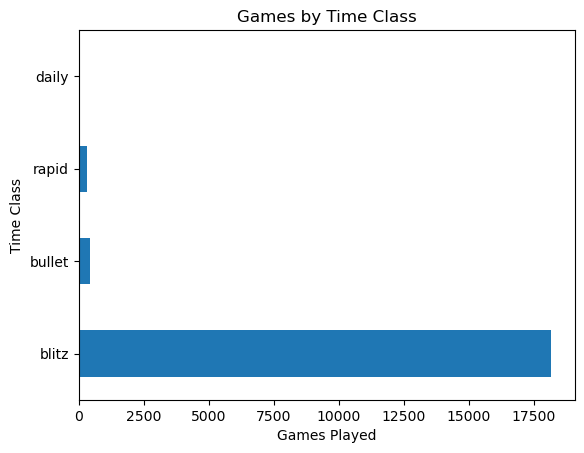

In [129]:
df["time_class"].value_counts().plot(
    kind="barh"
)

plt.title("Games by Time Class")
plt.xlabel("Games Played")
plt.ylabel("Time Class")

plt.show()

### Time control

Total amount of time a player has in a single game

In [130]:
df["time_control"].value_counts()

time_control
180          14979
300           2970
60             449
600            303
180+2          209
1/86400         23
1/259200        18
1/604800        10
1/1209600        4
1800             3
3600             2
Name: count, dtype: int64

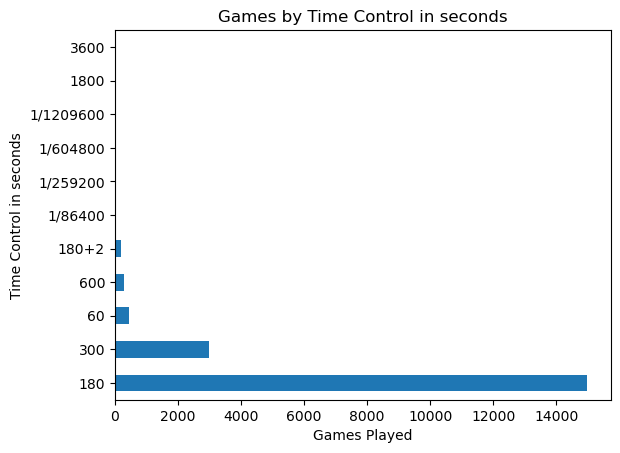

In [131]:
df["time_control"].value_counts().plot(
    kind="barh"
)

plt.title("Games by Time Control in seconds")
plt.xlabel("Games Played")
plt.ylabel("Time Control in seconds")

plt.show()

## Rating progression on short formats

We will take into considerations the shortest time classes: rapid, bullet and blitz (the most popular)

### Rapid - 10 minutes per game



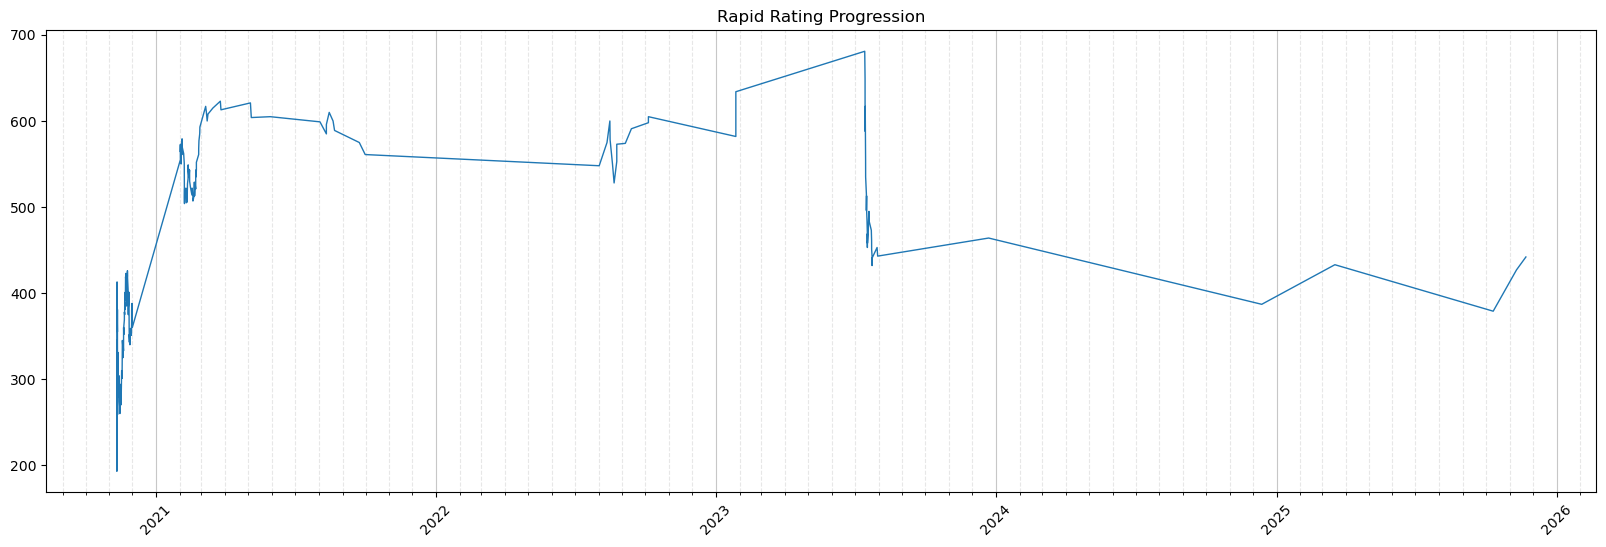

In [132]:
rapid = df[
    df["time_class"] == "rapid"
].sort_values("date")

plt.figure(figsize=(20,6))
ax = plt.gca() # Ottieni gli assi correnti

plt.plot(rapid["date"], rapid["player_rating"], linewidth=1)

# --- CONFIGURAZIONE DATE ---

# 1. Imposta una tacca principale per ogni inizio anno (es. 2023, 2024)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Mostra solo l'anno

# 2. Imposta tacche secondarie per ogni mese
ax.xaxis.set_minor_locator(mdates.MonthLocator())
# Opzionale: mostra il formato "Mese Anno" (es. Jan 2023) 
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Aggiungi una griglia per i mesi (linee leggere)
plt.grid(True, which='minor', axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which='major', axis='x', linestyle='-', alpha=0.7)

# Ruota le date per evitare sovrapposizioni
plt.xticks(rotation=45)

plt.title("Rapid Rating Progression")
plt.show()

### Bullet - 1 minute per game

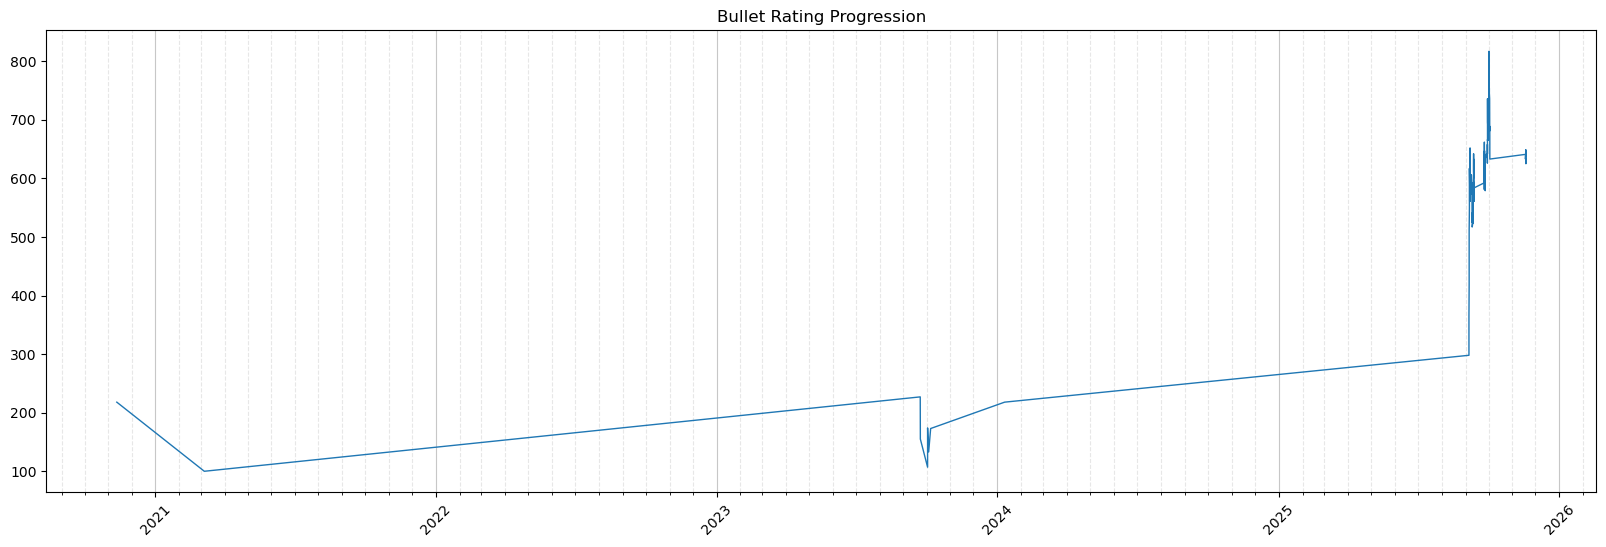

In [133]:
bullet = df[
    df["time_class"] == "bullet"
].sort_values("date")

plt.figure(figsize=(20,6))
ax = plt.gca() # Ottieni gli assi correnti

plt.plot(bullet["date"], bullet["player_rating"], linewidth=1)

# --- CONFIGURAZIONE DATE ---

# 1. Imposta una tacca principale per ogni inizio anno (es. 2023, 2024)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Mostra solo l'anno

# 2. Imposta tacche secondarie per ogni mese
ax.xaxis.set_minor_locator(mdates.MonthLocator())
# Opzionale: mostra il formato "Mese Anno" (es. Jan 2023) 
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Aggiungi una griglia per i mesi (linee leggere)
plt.grid(True, which='minor', axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which='major', axis='x', linestyle='-', alpha=0.7)

# Ruota le date per evitare sovrapposizioni
plt.xticks(rotation=45)

plt.title("Bullet Rating Progression")
plt.show()

### Blitz - 3 or 5 minutes per game 

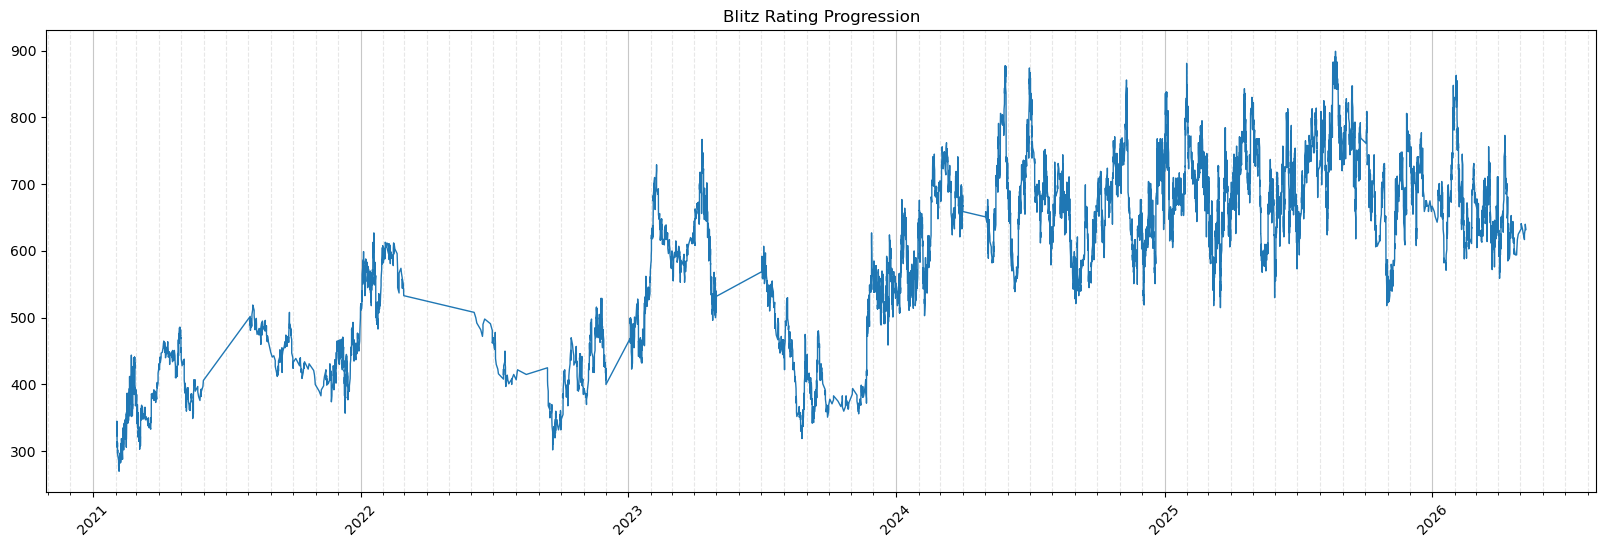

In [134]:
blitz = df[
    df["time_class"] == "blitz"
].sort_values("date")

plt.figure(figsize=(20,6))
ax = plt.gca() # Ottieni gli assi correnti

plt.plot(blitz["date"], blitz["player_rating"], linewidth=1)

# --- CONFIGURAZIONE DATE ---

# 1. Imposta una tacca principale per ogni inizio anno (es. 2023, 2024)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Mostra solo l'anno

# 2. Imposta tacche secondarie per ogni mese
ax.xaxis.set_minor_locator(mdates.MonthLocator())
# Opzionale: mostra il formato "Mese Anno" (es. Jan 2023) 
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Aggiungi una griglia per i mesi (linee leggere)
plt.grid(True, which='minor', axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which='major', axis='x', linestyle='-', alpha=0.7)

# Ruota le date per evitare sovrapposizioni
plt.xticks(rotation=45)

plt.title("Blitz Rating Progression")
plt.show()

### Plot of Rating progression for all major Time Classes

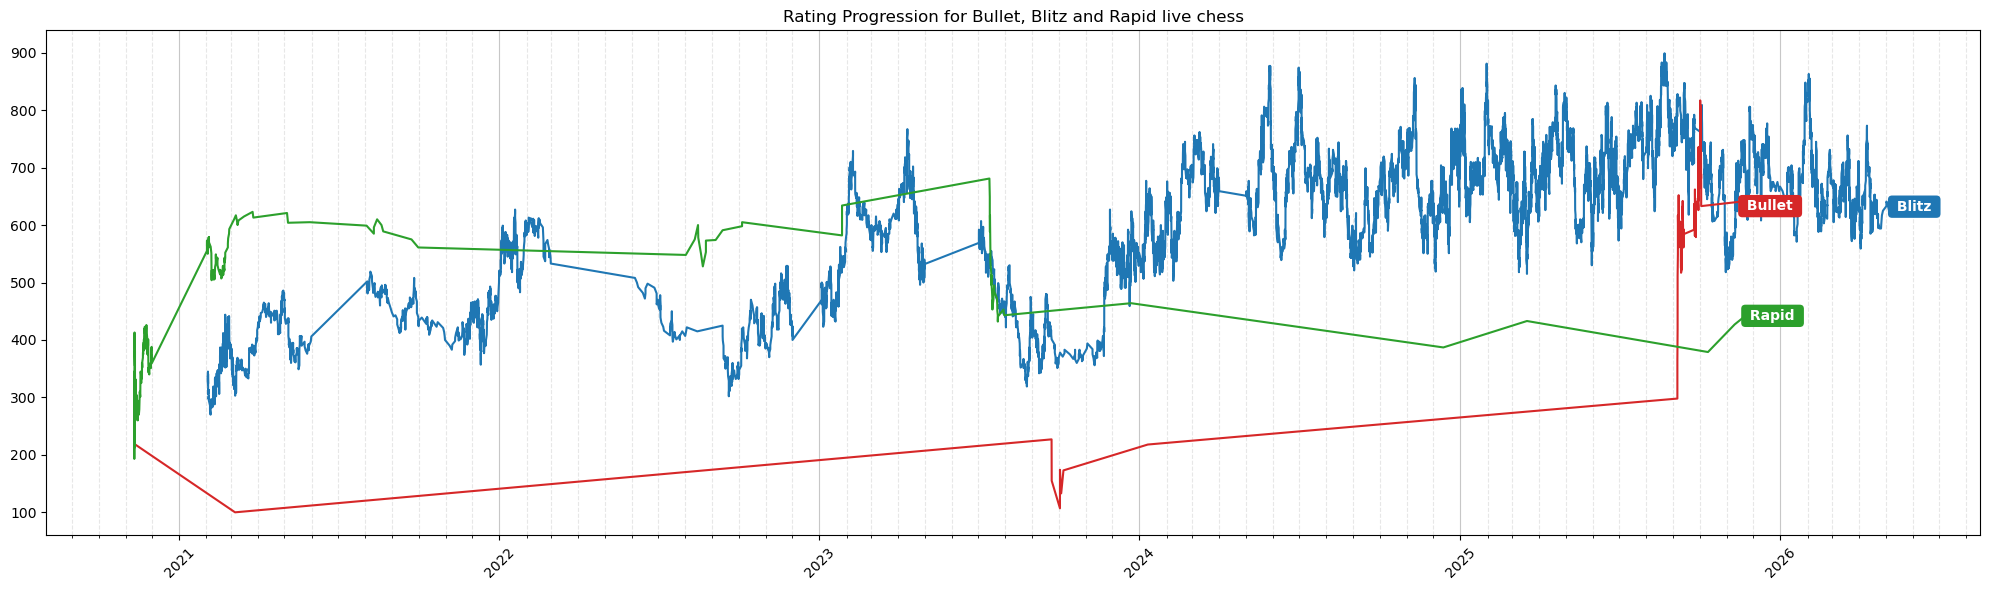

In [135]:
plt.figure(figsize=(20, 6))
ax = plt.gca()

# 1. Definiamo i colori personalizzati
colori = {
    "blitz": "#1f77b4",  # Blu
    "bullet": "#d62728", # Rosso
    "rapid": "#2ca02c"   # Verde
}

# --- PLOT DELLE LINEE ---
plt.plot(blitz["date"], blitz["player_rating"], color=colori["blitz"], linewidth=1.5)
plt.plot(bullet["date"], bullet["player_rating"], color=colori["bullet"], linewidth=1.5)
plt.plot(rapid["date"], rapid["player_rating"], color=colori["rapid"], linewidth=1.5)

# --- CONFIGURAZIONE DATE E GRIGLIA ---
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
plt.grid(True, which='minor', axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which='major', axis='x', linestyle='-', alpha=0.7)
plt.xticks(rotation=45)

# --- FUNZIONE PER AGGIUNGERE LABEL COLORATE ---
def add_label(df, label_text, color):
    last_date = df["date"].iloc[-1]
    last_rating = df["player_rating"].iloc[-1]
    
    plt.text(
        last_date, last_rating, f' {label_text} ', 
        color='white',            # Colore del testo
        fontweight='bold', 
        va='center',
        bbox=dict(
            facecolor=color,      # Colore di sfondo uguale alla linea
            edgecolor='none',     # Rimuove il bordo del rettangolo
            boxstyle='round,pad=0.3' # Arrotonda i bordi e aggiunge spaziatura
        )
    )

# 2. Applichiamo le label
add_label(blitz, "Blitz", colori["blitz"])
add_label(bullet, "Bullet", colori["bullet"])
add_label(rapid, "Rapid", colori["rapid"])

plt.title("Rating Progression for Bullet, Blitz and Rapid live chess")

# Aggiunge un po' di spazio a destra per non far uscire le label dal grafico
plt.tight_layout() 
plt.show()


## White vs Black analysis

In [136]:
df.groupby("side")["score"].mean()

side
black    0.474111
white    0.525929
Name: score, dtype: float64

In [137]:
white_black = (
    df.groupby("side")
    .agg({
        "score": "mean",
        "player_rating": "mean"
    })
)

white_black

,score,player_rating
side,,
black,0.474111,636.601452
white,0.525929,637.297106


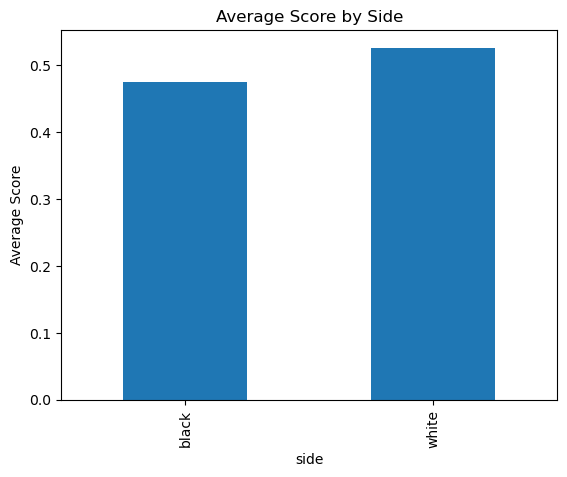

In [138]:
white_black["score"].plot(
    kind="bar"
)

plt.title("Average Score by Side")
plt.ylabel("Average Score")

plt.show()

## Performance by hour

### Games count

In [139]:
df["hour"].value_counts().sort_index()

hour
0      702
1      262
2      100
3       43
4        8
5        5
6        8
7      104
8      801
9      609
10     813
11    1083
12    1255
13     894
14    1256
15    1293
16    1097
17     957
18    1010
19     890
20    1396
21    1470
22    1606
23    1308
Name: count, dtype: int64

### Winrate by hour

In [140]:
hourly = (
    df.groupby("hour")
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "url": "games"
    })
)

hourly

,score,games
hour,,
0,0.517094,702
1,0.484733,262
2,0.480000,100
3,0.441860,43
4,0.625000,8
5,0.600000,5
6,0.125000,8
7,0.504808,104
8,0.487516,801


### Plot

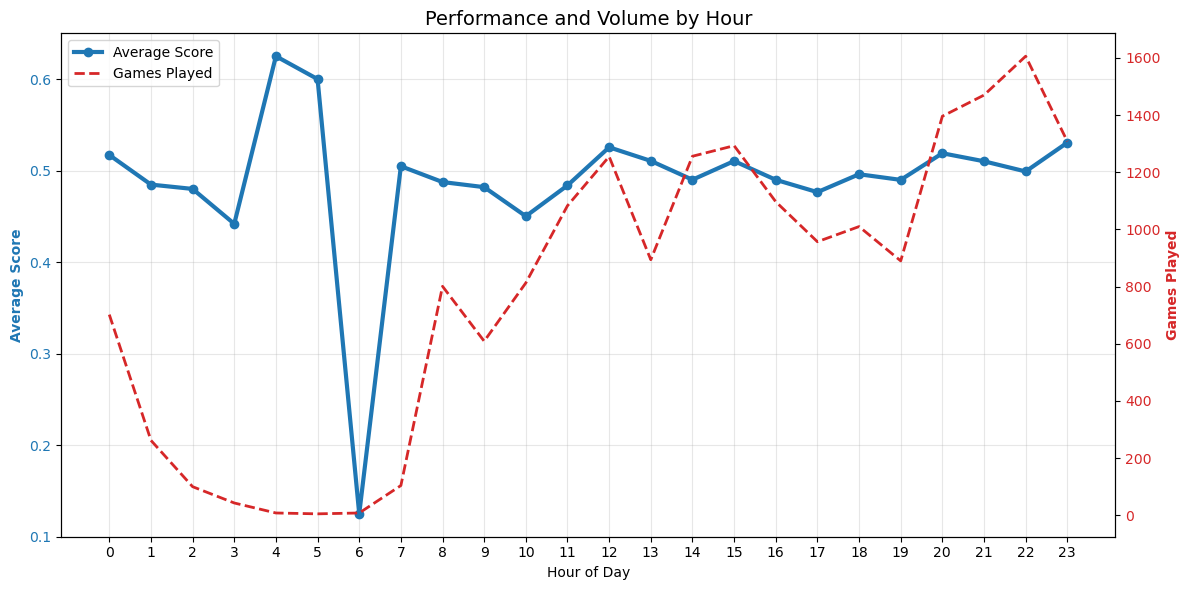

In [141]:
plt.figure(figsize=(12, 6))

# --- PRIMA SERIE: Score (Asse Y Sinistro) ---
ax1 = plt.gca() # Ottieni l'asse corrente
ax1.plot(
    hourly.index,
    hourly["score"],
    color="tab:blue",
    linewidth=3,
    label="Average Score",
    marker='o' # Aggiunge dei punti per ogni ora
)
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Average Score", color="tab:blue", fontweight="bold")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_xticks(range(24))

# --- SECONDA SERIE: Games (Asse Y Destro) ---
ax2 = ax1.twinx() # Crea un secondo asse che condivide l'asse X
ax2.plot(
    hourly.index,
    hourly["games"],
    color="tab:red",
    linewidth=2,
    linestyle="--", # Linea tratteggiata per distinguerla
    label="Games Played"
)
ax2.set_ylabel("Games Played", color="tab:red", fontweight="bold")
ax2.tick_params(axis='y', labelcolor="tab:red")

# --- TITOLO E GRIGLIA ---
plt.title("Performance and Volume by Hour", fontsize=14)
ax1.grid(True, alpha=0.3) # Griglia leggera basata sull'asse principale

# Opzionale: Unire le legende di entrambi gli assi
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


## Opening analysis

### Minimum games filter

We are looking at openings that have been used at least 500 times

In [142]:
opening_stats = (
    df.groupby(["opening","side"])
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "url": "games"
    }) .sort_values(by="score", ascending=False)
)

opening_stats = opening_stats[
    opening_stats["games"] >= 500
]

### Most Used Openings

In [143]:
opening_stats.sort_values(
    "games",
    ascending=False
).reset_index().head(10)

,opening,side,score,games
0,Four Knights Game Scotch Variation Accepted,white,0.529477,899
1,Vienna Game,white,0.604238,873
2,Three Knights Opening,white,0.540865,832
3,Kings Pawn Opening,black,0.557437,827
4,Scandinavian Defense Closed,white,0.434691,712


### Best openings

In [144]:
opening_stats.sort_values(
    "score",
    ascending=False
).reset_index().head(10)

,opening,side,score,games
0,Vienna Game,white,0.604238,873
1,Kings Pawn Opening,black,0.557437,827
2,Three Knights Opening,white,0.540865,832
3,Four Knights Game Scotch Variation Accepted,white,0.529477,899
4,Scandinavian Defense Closed,white,0.434691,712


## Rating difference analysis

How do I perform against better rated opponents?

### Bucket ratings

In [145]:
df["rating_bucket"] = pd.cut(
    df["rating_diff"],
    bins=[
        -1000,
        -300,
        -100,
        100,
        300,
        1000
    ]
)

### Performance

In [146]:
rating_perf = (
    df.groupby(["rating_bucket"], observed=False)
    ["score"]
    .mean()
)

rating_perf

rating_bucket
(-1000, -300]    0.000000
(-300, -100]     0.130435
(-100, 100]      0.498626
(100, 300]       0.941748
(300, 1000]      1.000000
Name: score, dtype: float64

### Plot

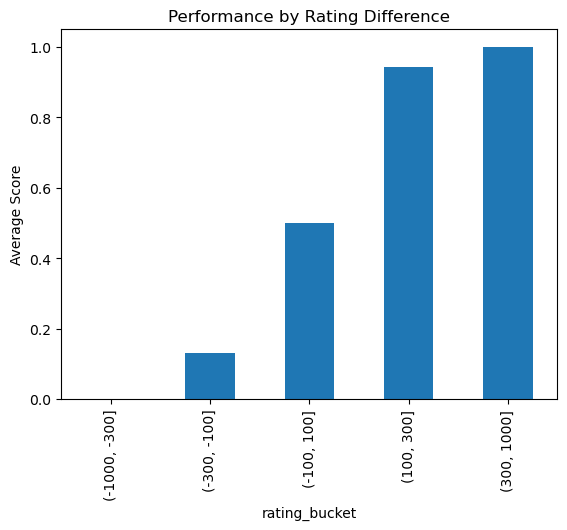

In [147]:
rating_perf.plot(kind="bar")

plt.title(
    "Performance by Rating Difference"
)

plt.ylabel("Average Score")

plt.show()

## How I win, lose or draw

### Data Prep

In [148]:
wins = df[df['result'] == 'win' ]
draws = df[df['result'] == 'draw' ]
losses = df[df['result'] == 'loss' ]

In [149]:
wins_perc = wins.groupby(['opponent_result'])['result'].count().reset_index(name='count')

wins_perc['percentage'] = round((wins_perc['count'] / wins_perc['count'].sum()) * 100,2)

draws_perc = draws.groupby(['opponent_result'])['result'].count().reset_index(name='count')

draws_perc['percentage'] = round((draws_perc['count'] / draws_perc['count'].sum()) * 100,2)

losses_perc = losses.groupby(['player_result'])['result'].count().reset_index(name='count')

losses_perc['percentage'] = round((losses_perc['count'] / losses_perc['count'].sum()) * 100,2)


### Plot

In [150]:
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"#a099ff"]

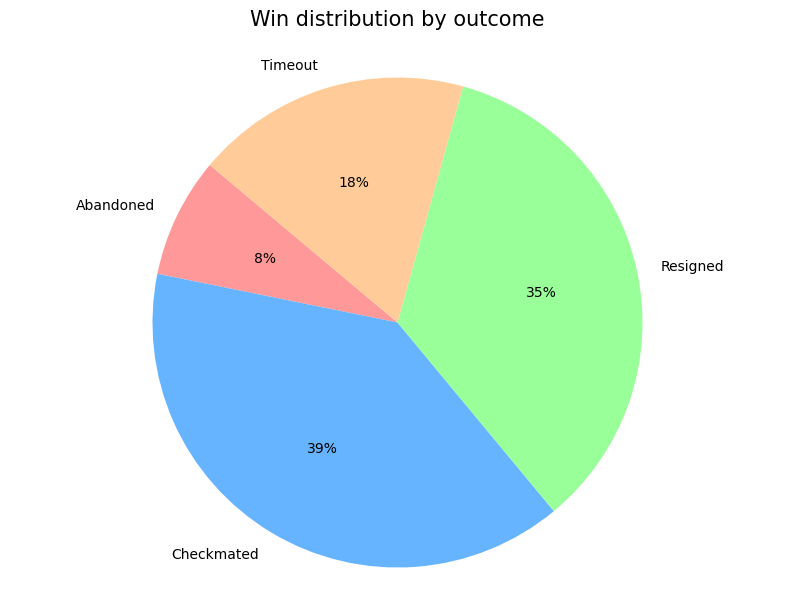

In [151]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    wins_perc['count'], 
    labels=[n.title() for n in wins_perc['opponent_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Win distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

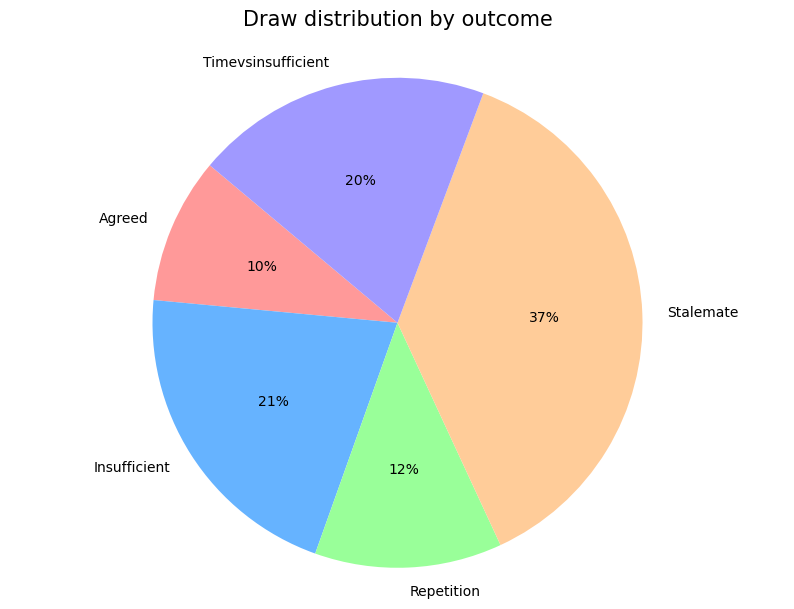

In [152]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    draws_perc['count'], 
    labels=[n.title() for n in draws_perc['opponent_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Draw distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

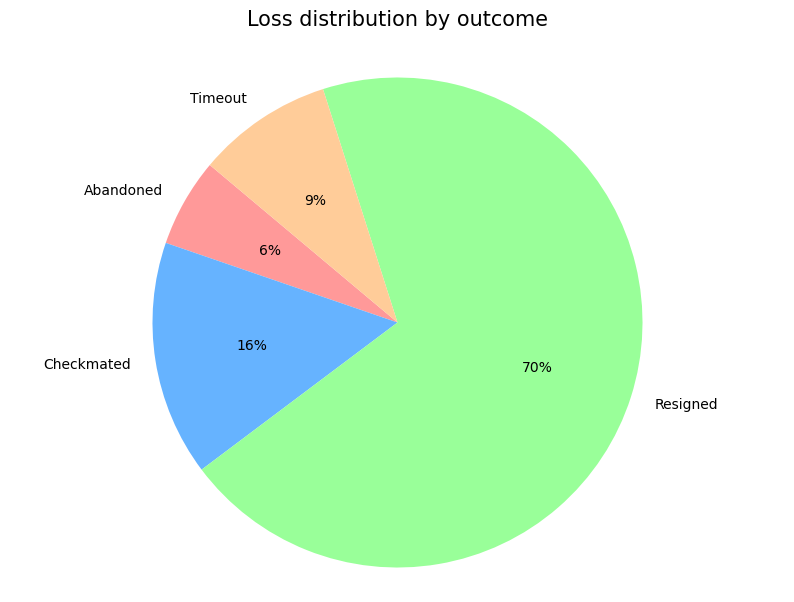

In [153]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    losses_perc['count'], 
    labels=[n.title() for n in losses_perc['player_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Loss distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

## Weekday performance

In [154]:
weekday_perf = (
    df.groupby("weekday")
    ["score"]
    .mean()
)

weekday_perf

weekday
Friday       0.507099
Monday       0.505151
Saturday     0.498370
Sunday       0.488388
Thursday     0.491750
Tuesday      0.512186
Wednesday    0.497222
Name: score, dtype: float64

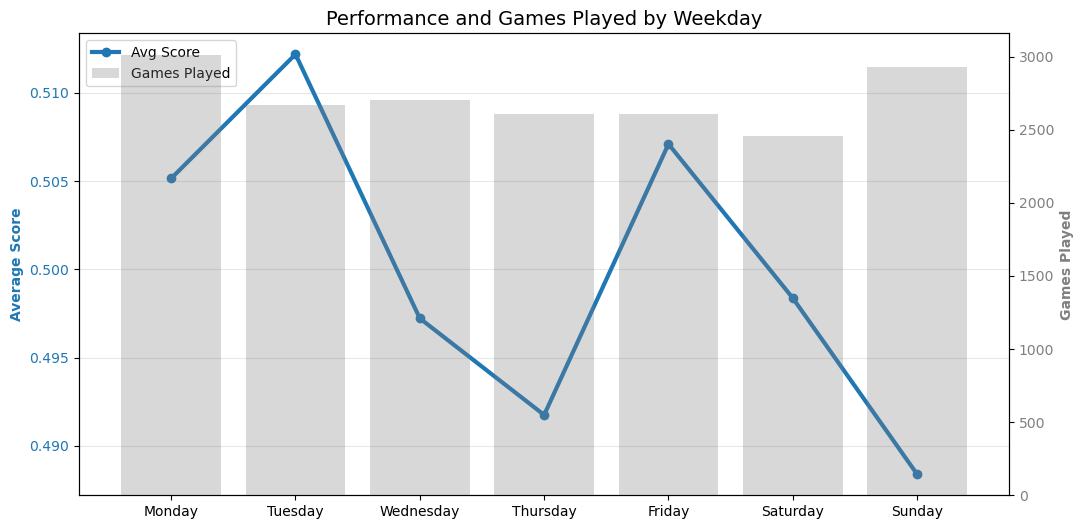

In [155]:
weekday_stats = (
    df.groupby("weekday")
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={"url": "games"})
)

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_stats = weekday_stats.reindex(days_order)

plt.figure(figsize=(12, 6))

ax1 = plt.gca()
ax1.plot(weekday_stats.index, weekday_stats["score"], color="tab:blue", marker='o', linewidth=3, label="Avg Score")
ax1.set_ylabel("Average Score", color="tab:blue", fontweight="bold")
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.bar(weekday_stats.index, weekday_stats["games"], color="tab:gray", alpha=0.3, label="Games Played")
ax2.set_ylabel("Games Played", color="tab:gray", fontweight="bold")
ax2.tick_params(axis='y', labelcolor="tab:gray")

plt.title("Performance and Games Played by Weekday", fontsize=14)
ax1.grid(True, axis='y', alpha=0.3)

lines, labels = ax1.get_legend_handles_labels()
bars, labels_b = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + labels_b, loc="upper left")

plt.show()


## Geographical analysis

### Cleaning

In [156]:
geo_games = df.dropna()
geo_games["country_code"].isna().mean()

np.float64(0.0)

### Aggregation

In [157]:
country_counts = (
    geo_games["country_code"]
    .value_counts()
    .reset_index()
)

country_counts.columns = [
    "country_code",
    "games"
]

country_counts.head()

,country_code,games
0,US,1129
1,IN,555
2,GB,297
3,FR,295
4,DE,258


### Convert ISO-2 → ISO-3

In [ ]:
import pycountry

def get_country_info(code):

    try:

        country = pycountry.countries.get(
            alpha_2=code
        )

        return pd.Series({

            "iso3": country.alpha_3,

            "country_name": country.name
        })

    except:

        return pd.Series({

            "iso3": None,

            "country_name": None
        })

In [ ]:
country_counts[
    ["iso3", "country_name"]
] = country_counts[
    "country_code"
].apply(get_country_info)

In [160]:
# drop missing

country_counts = country_counts.dropna(
    subset=["iso3"]
)

### Plotly choropleth

In [ ]:
import plotly.express as px

country_counts["games_log"] = np.log10(
    country_counts["games"]
)

fig = px.choropleth(

    country_counts,

    locations="iso3",

    locationmode="ISO-3",

    color="games_log",

    hover_name="country_name",

    hover_data={
        "games": True,
        "games_log": False,
        "iso3": False
    },

    color_continuous_scale="Viridis",

    projection="natural earth",

    title=(
        f"Over 20,000 Chess Games Across "
        f"{len(country_counts)} Countries"
    )
)

fig.update_layout(

    width=1400,
    height=700,

    margin=dict(
        l=0,
        r=0,
        t=60,
        b=0
    )
)

fig.update_geos(

    showframe=False,
    showcoastlines=True,

    projection_type="natural earth"
)

fig.show()

## Correlation analysis

In [162]:
numeric_cols = [
    "player_rating",
    "opponent_rating",
    "rating_diff",
    "score"
]

df[numeric_cols].corr()

,player_rating,opponent_rating,rating_diff,score
player_rating,1.000000,0.950752,0.030843,0.032773
opponent_rating,0.950752,1.000000,-0.280481,-0.125398
rating_diff,0.030843,-0.280481,1.000000,0.505869
score,0.032773,-0.125398,0.505869,1.000000


# Initial Findings

Some interesting early observations:

- Performance appears to vary significantly by hour of day
- Certain openings consistently outperform others
- White and Black performance differ noticeably
- Rating difference heavily impacts expected results

## Export Tables

In [163]:
EXPORT_DIR = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
)

opening_stats.to_csv(
    EXPORT_DIR / "opening_stats.csv"
)

hourly.to_csv(
    EXPORT_DIR / "hourly_performance.csv"
)